Please make sure you have read the [Getting Started page](https://pyrealm.readthedocs.io/en/latest/users/getting_started.html) before attempting to run this notebook.

# Soil moisture effects

Approaches to modelling the impact of soil moisture conditions on photosynthesis are a
very open area and a number of different methods are implemented in `pyrealm`. These
different approaches reflect uncertainty about the most appropriate way to modulate
predictions.

### Warning
The soil moisture approaches described on this page should not be combined with each
other. In addition, some of these methods were calibrated for a particular form of the
P Model or with particular settings and so should be used with models that follow those
particular settings.

## Alternative approaches

### Effects on [optimal chi](https://pyrealm.readthedocs.io/en/latest/users/pmodel/shared_components/optimal_chi.html)

The `pyrealm` package includes two separate approaches that affect optimal chi:

* The `lavergne20_c3` (`OptimalChiLavergne20C3`)
 and `lavergne20_c4` (`OptimalChiLavergne20C4`)
 methods , which use an empirical model of the change in the ratio of the
 photosynthetic costs of carboxilation and transpiration.

* The experimental optimal chi methods that impose a direct rootzone stress penalty
 on the $\beta$ term in calculating optimal chi: `prentice14_rootzonestress`
 (`OptimalChiPrentice14RootzoneStress`),
 `c4_rootzonestress` (`OptimalChiC4RootzoneStress`), and
 `c4_no_gamma_rootzonestress` (`OptimalChiC4NoGammaRootzoneStress`)

### Effects on the [quantum yield of photosynthesis](https://pyrealm.readthedocs.io/en/latest/users/pmodel/shared_components/quantum_yield.html)

* The `sandoval` method (`QuantumYieldSandoval`)
 implements an experimental calculation that modulates $\phi_0$ as a function of the
 temperature and a local aridity index.

### Post-hoc penalties on gross primary productivity

These approaches both use empirical
functions of soil moisture and aridity data that have been parameterised to align
raw predictions from a P Model with field observations of GPP. Two penalty function
are available that calculate the fraction of potential GPP that is realised given the
effects of soil moisture stress:

* The `calc_soilmstress_stocker` function implements the Stocker2020dh GPP penalty for use with the standard P Model.
* `calc_soilmstress_mengoli` function implements the
  Mengoli2023a GPP penalty for use with the subdaily P Model.

The GPP penalty functions are described in more detail below, using the artificial data
set created below. The data set consists of 5 days of observations of a constant
environment that can be used to show the effects of changing soil moisture input values
on the resulting GPP.

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from pyrealm.constants import PModelConst
from pyrealm.pmodel import (
    AcclimationModel,
    PModel,
    PModelEnvironment,
    SubdailyPModel,
    calc_soilmstress_mengoli,
    calc_soilmstress_stocker,
)

# Create a test data set consisting of 5 days of observations of a constant environment
# that can be used to show the effects of changing soil moisture input values on the
# resulting GPP
n_obs = 48 * 5
obs_minutes = 30
time_offsets = np.arange(0, n_obs * obs_minutes, obs_minutes).astype("timedelta64[m]")
datetimes = np.datetime64("2000-01-01 00:00") + time_offsets

# Constant P Model enviroment
env = PModelEnvironment(
    tc=np.full(n_obs, fill_value=20),
    patm=np.full(n_obs, fill_value=101325),
    vpd=np.full(n_obs, fill_value=820),
    co2=np.full(n_obs, fill_value=400),
    fapar=np.full(n_obs, fill_value=1),
    ppfd=np.full(n_obs, fill_value=1000),
)

# Soil moisture gradient across the observations
sm_gradient = np.linspace(0, 1.0, n_obs)

## The `calc_soilmstress_stocker` penalty factor

This calculates an empirically derived penalty factor based on soil moisture ($\theta$)
(Stocker2018be,Stocker2020dh) that captures the loss of gross primary
productivity (GPP) resulting from soil moisture stress.

The factor $\beta(\theta) \in [0,1]$ requires estimates of:

* relative soil moisture ($m_s$, `soilm`), as the fraction of field capacity, and
* a measure of local mean aridity ($\bar{\alpha}$, `meanalpha`), as the average annual
  ratio of AET to PET.

### Soil moisture
The parameters used in the calculation of this factor were estimated using the
plant-available soil water expressed as a fraction of available water holding capacity.
That capacity was calculated for the observed data on a site by site basis using the
`SoilGrids` dataset (Hengl2017a). Ideally, soil moisture calculated in the same
way should be used with this approach.


The functions to calculate $\beta(\theta)$ are based on four parameters, derived from
experimental data and set in `pmodel_const.PModelConst`:

* An upper bound in relative soil moisture ($\theta^\ast$, `soilmstress_thetastar`),
  above which $\beta$ is always 1, corresponding to no loss of light use efficiency.
* An lower bound in relative soil moisture ($\theta_0$, `soilmstress_theta0`),
  below which LUE is always zero.
* An intercept (a, `soilmstress_a`) for the aridity sensitivity parameter $q$.
* A slope (b, `soilmstress_b`) for the aridity sensitivity parameter $q$.

The aridity measure ($\bar{\alpha}$) is first used to set an aridity sensitivity
parameter ($q$), which sets the speed with which $\beta(\theta) \to 0$ as $m_s$
decreases.

$$
    q = \frac{(1 - (a + b \bar{\alpha}))}{(\theta^\ast - \theta_{0})^2}
$$

Then, relative soil moisture ($m_s$) is used to calculate the soil moisture factor:

$$
    \beta(\theta) = q ( m_s - \theta^\ast) ^ 2  + 1
$$

The figures below shows how the aridity sensitivity parameter ($q$) changes with
differing aridity measures and then how the soil moisture factor $\beta(\theta)$
varies with changing soil moisture for differing values of mean aridity. In
the examples below, the default $\theta_0 = 0$ has been changed to $\theta_0 =
0.1$ to make the lower bound more obvious.

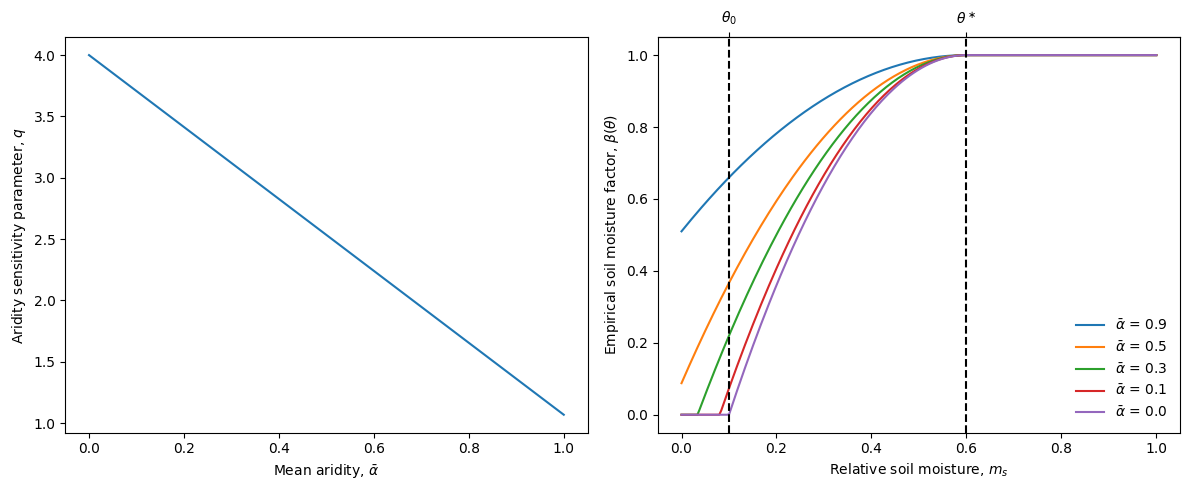

In [2]:
# change default theta0 parameter
coef = PModelConst().soilmstress_stocker
coef["theta0"] = 0.1

# Calculate q
mean_alpha_seq = np.linspace(0, 1, n_obs)

q = (1 - (coef["a"] + coef["b"] * mean_alpha_seq)) / (
    coef["thetastar"] - coef["theta0"]
) ** 2

# Create a 1x2 plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot q ~ mean_alpha
ax1.plot(mean_alpha_seq, q)
ax1.set_xlabel(r"Mean aridity, $\bar{\alpha}$")
ax1.set_ylabel(r"Aridity sensitivity parameter, $q$")


for mean_alpha in [0.9, 0.5, 0.3, 0.1, 0.0]:
    soilmstress = calc_soilmstress_stocker(
        soilm=sm_gradient, meanalpha=mean_alpha, coef=coef
    )
    ax2.plot(sm_gradient, soilmstress, label=rf"$\bar{{\alpha}}$ = {mean_alpha}")

ax2.axvline(x=coef["thetastar"], linestyle="--", color="black")
ax2.axvline(x=coef["theta0"], linestyle="--", color="black")

secax = ax2.secondary_xaxis("top")
secax.set_xticks(
    ticks=[coef["thetastar"], coef["theta0"]],
    labels=[r"$\theta^\ast$", r"$\theta_0$"],
)

ax2.legend(frameon=False)
ax2.set_xlabel(r"Relative soil moisture, $m_s$")
ax2.set_ylabel(r"Empirical soil moisture factor, $\beta(\theta)$")

plt.tight_layout()

### Application of the `functions.calc_soilmstress_stocker` factor

The factor can be applied to the P Model by using
`calc_soilmstress_stocker` to calculate the factor
values and then multiplying calculated GPP (`PModel.gpp`)
by the resulting factor. The example below shows how the predicted light use
efficiency from the P Model changes across an aridity gradient both with and without the
soil moisture factor.

In the `rpmodel` implementation, the soil moisture factor is applied within the
calculation of the P Model and the penalised GPP is used to modify $V_{cmax}$ and
$J_{max}$, so that these values are congruent with the resulting penalised LUE and GPP.
This is **not** implemented in the `pmodel` module, where
correction is only implemented as a post-hoc penalty to GPP.

### Caution
* This soil moisture stress function was parameterised using the standard P Model
  (`PModel`) and is unlikely to transfer well to GPP
  predictions from the subdaily form of the model (`SubdailyPModel`).

* The parameterisation of this soil moisture stress function formed part of a wider
  model tuning in Stocker2020dh that also adjusted the value of the
  quantum yield of photosynthesis to capture canopy scale efficiency. To match this
  calibration process, the correction should be applied to outputs of a `PModel` with
  matching settings: see `calc_soilmstress_stocker` for details.

pyrealm/pmodel.py:409: UserWarning: 
    Pyrealm 2.0.0 uses a new default for the quantum yield of photosynthesis (phi0=1/8).
    You may need to change settings to duplicate results from pyrealm 1.0.0.
            


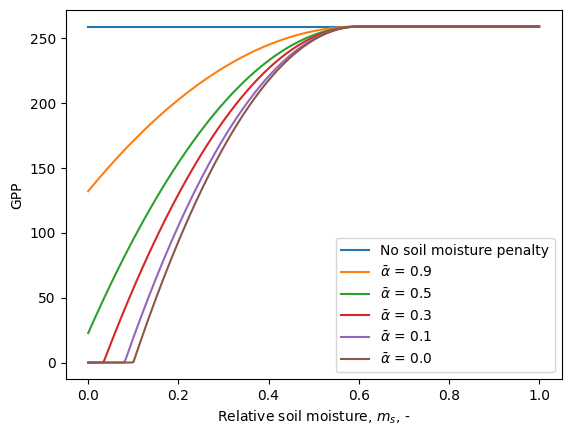

In [3]:
# Configure the PModel to use the 'BRC' model setup of Stocker et al. (2020)
model = PModel(
    env=env,
    method_kphio="temperature",
    method_arrhenius="simple",
    method_jmaxlim="wang17",
    method_optchi="prentice14",
    reference_kphio=0.081785,
)

# Calculate the soil moisture stress factor across a soil moisture gradient
# at differing aridities

gpp_stressed = {}

for mean_alpha in [0.9, 0.5, 0.3, 0.1, 0.0]:
    # Calculate the stress for this aridity
    sm_stress = calc_soilmstress_stocker(
        soilm=sm_gradient, meanalpha=mean_alpha, coef=coef
    )
    # Apply the penalty factor
    gpp_stressed[mean_alpha] = model.gpp * sm_stress

plt.plot(sm_gradient, model.gpp, label="No soil moisture penalty")

for ky, val in gpp_stressed.items():
    plt.plot(sm_gradient, val, label=rf"$\bar{{\alpha}}$ = {ky}")

plt.xlabel(r"Relative soil moisture, $m_s$, -")
plt.ylabel(r"GPP")
plt.legend()
plt.show()

## The `calc_soilmstress_mengoli` penalty factor

This is an empirically derived factor ($\beta(\theta) \in [0,1]$,
Mengoli2023a that describes a penalty to gross primary productivity (GPP)
resulting from soil moisture stress.

The factor requires estimates of:

* relative soil moisture ($m_s$, `soilm`), as the fraction of field capacity, and
* a climatological estimate of local aridity index, typically calculated as total PET
  over total precipitation for an appropriate period, typically at least 20 years.

### Soil moisture

The parameters used in the calculation of this factor were estimated using the
plant-available soil water expressed as the ratio of millimeters of soil moisture over
the total soil capacity. The soil water estimated using CRU data in SPLASH v1 model
{cite:p}`davis:2017a`, which enforces a constant soil capacity of 150mm. Again, ideally,
soil moisture calculated in the same way should be used with this approach.

The calculation of $\beta(\theta)$ is based on two functions of the aridity index. Both
functions are power laws, constrained to take a maximum of 1 (no soil moisture stress
penalty). The first function describes the maximal attainable level ($y$) and the second
function describes a threshold ($\psi$) at which that level is reached. The parameters
of these power laws are derived from experimental data and set in `PModelConst`.

$$
\begin{align*}
y &= \min( a  \textrm{AI} ^ {b}, 1)\\
\psi &= \min( a  \textrm{AI} ^ {b}, 1)\\
\end{align*}
$$

The penalty factor $\beta(\theta)$ is then calculated given the relative soil moisture
$\theta$, the threshold $\psi$ and the maximum level:

$$
\beta(\theta) =
    \begin{cases}
        y, & \theta \ge \psi \\
        \dfrac{y}{\psi} \cdot \theta, & \theta \lt \psi
    \end{cases}
$$

The function for the maximum attainable level $y$ reaches the maximum value of 1 at:

$$
\textrm{AI} = e^{-log(a)/b}
$$

Given the default values, this critical level is around 0.3457: plants can only realise
the predicted GPP from the P Model in locations where the aridity index is less than
this value.

In [4]:
coef = PModelConst().soilmstress_mengoli
print(coef)

{'psi_a': 0.34, 'psi_b': -0.6, 'y_a': 0.62, 'y_b': -0.45}


In [5]:
AI_crit_y = np.exp(-np.log(coef["y_a"]) / coef["y_b"])
round(AI_crit_y, 4)

np.float64(0.3457)

pyrealm/<>:14: SyntaxWarning: invalid escape sequence '\p'
pyrealm/<>:14: SyntaxWarning: invalid escape sequence '\p'
pyrealm/2617339765.py:14: SyntaxWarning: invalid escape sequence '\p'


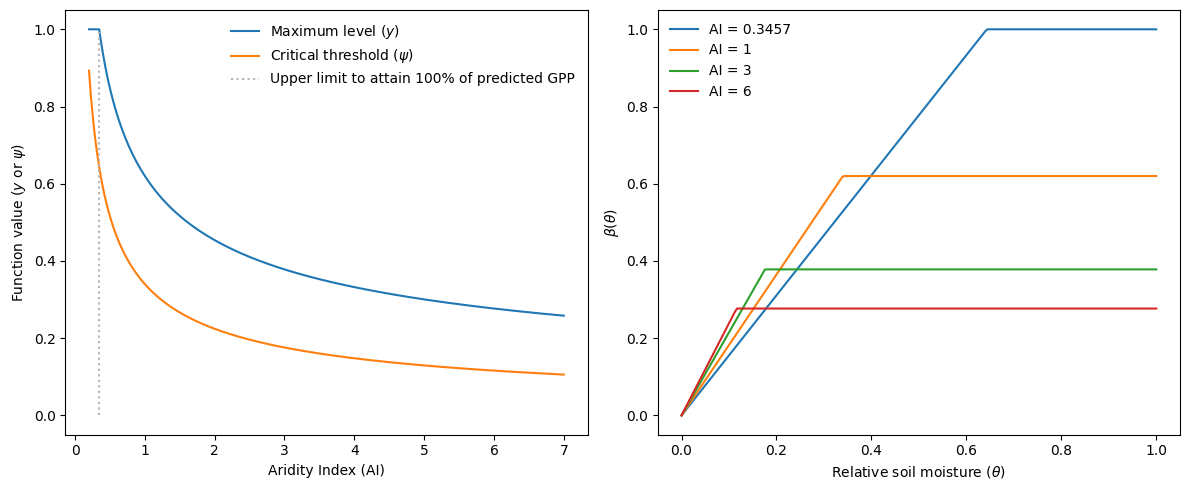

In [6]:
aridity_index = np.sort(np.concatenate([[AI_crit_y], np.linspace(0.2, 7, n_obs)]))

y = np.minimum(coef["y_a"] * np.power(aridity_index, coef["y_b"]), 1)

psi = np.minimum(
    coef["psi_a"] * np.power(aridity_index, coef["psi_b"]),
    1,
)

# Create a 1x2 plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(aridity_index, y, label="Maximum level (y)")
ax1.plot(aridity_index, psi, label="Critical threshold (psi)")
ax1.plot(
    [AI_crit_y, AI_crit_y],
    [0, 1],
    linestyle=":",
    color="0.7",
    label="Upper limit to attain 100% of predicted GPP",
)
ax1.set_xlabel(r"Aridity Index (AI)")
ax1.set_ylabel(r"Function value (y or psi)")
ax1.legend(frameon=False)


# Calculate the soil moisture stress factor across a soil moisture
# gradient for different aridity index values
beta = {}
ai_vals = [AI_crit_y.round(4), 1, 3, 6]

for ai in ai_vals:
    beta[ai] = calc_soilmstress_mengoli(soilm=sm_gradient, aridity_index=np.array(ai))
    plt.plot(sm_gradient, beta[ai], label=f"AI = {ai}")

ax2.set_xlabel(r"Relative soil moisture (theta)")
ax2.set_ylabel(r"beta(theta)")
ax2.legend(frameon=False)

plt.tight_layout()

In [7]:
np.exp(-np.log(0.62) / -0.45)

np.float64(0.3456592624095148)

As the plots above show, plants in arid conditions have severely constrained maximum
levels, but have lower critical thresholds, allowing them to maintain the maximum level
under drier conditions.

### Application of the `calc_soilmstress_mengoli` factor

As with  `calc_soilmstress_stocker`, the factor is first
calculated and then applied to the GPP calculated for a model
(`PModel.gpp`). In the example below, the result is
obviously just $\beta(\theta)$ from above scaled to the constant GPP.

### Caution
* This soil moisture stress function was parameterised using the subdaily P Model
  (`SubdailyPModel`) and is unlikely to transfer well
  to GPP predictions from the standard form of the model
  (`PModel`).

* The parameterisation of this soil moisture stress function was estimated using
  predictions from a particular parameterisation of the subdaily PModel. To match
  the parameterisation settings, the correction should be applied to outputs of a
  `SubdailyPModel` with matching settings: see `calc_soilmstress_mengoli` for details.
```

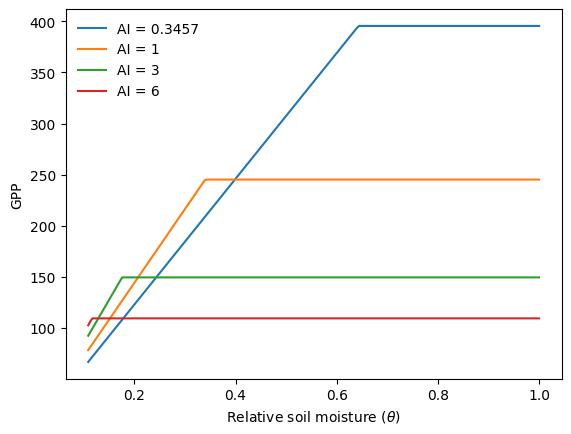

In [8]:
acclim_model = AcclimationModel(datetimes=datetimes)
acclim_model.set_window(
    window_center=np.timedelta64(12, "h"), half_width=np.timedelta64(1, "h")
)

subdaily_model = SubdailyPModel(
    env=env,
    acclim_model=acclim_model,
    method_kphio="temperature",
    method_arrhenius="simple",
    method_jmaxlim="wang17",
    method_optchi="prentice14",
    reference_kphio=1 / 8,
)

for ai in ai_vals:
    plt.plot(sm_gradient, subdaily_model.gpp * beta[ai], label=f"AI = {ai}")

plt.xlabel(r"Relative soil moisture ($\theta$)")
plt.ylabel("GPP")
plt.legend(frameon=False)
plt.show()